Loan Approval or Rejected 

0 -> Rejected 

1 -> Approved 

Target Column => Loan_approved

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("./loan_approval_1000.csv")
df.head(5)

,Age,Income,Loan_Amount,Credit_Score,Employment_Type,Loan_Approved
0,59,77761.0,417505,337,Salaried,0
1,49,141178.0,328226,487,Salaried,0
2,35,56368.0,312805,356,Self-Employed,0
3,28,26783.0,218484,319,Salaried,0
4,41,131530.0,315064,572,Self-Employed,0


In [3]:
df.isna().sum()

Age                 0
Income             50
Loan_Amount         0
Credit_Score        0
Employment_Type    50
Loan_Approved       0
dtype: int64

In [4]:
df.shape

(1000, 6)

In [5]:
df.describe()

,Age,Income,Loan_Amount,Credit_Score,Loan_Approved
count,1000.000000,950.000000,1000.000000,1000.000000,1000.000000
mean,40.445000,84881.753684,270051.753000,610.381000,0.315000
std,11.499183,37717.819324,128863.845332,174.696974,0.464748
min,21.000000,20060.000000,51969.000000,300.000000,0.000000
25%,30.000000,51909.000000,160877.250000,460.000000,0.000000
50%,41.000000,83551.500000,266606.500000,612.000000,0.000000
75%,50.000000,116955.750000,383224.500000,764.000000,1.000000
max,59.000000,149972.000000,499370.000000,898.000000,1.000000


Null Imputation

> Income  - Numeric Data.... So we can put the mean value on the null place

> Employment Type - categorical data.... so we can put the most repeated value on the null place

In [6]:
mean = df["Income"].mean()
mean

np.float64(84881.75368421053)

In [7]:
df["Income"] = df["Income"].fillna(mean)

In [8]:
df["Employment_Type"].value_counts()

Employment_Type
Salaried         471
Self-Employed    287
Unemployed       192
Name: count, dtype: int64

In [9]:
mode = df["Employment_Type"].mode()[0]        
mode

'Salaried'

In [10]:
df["Employment_Type"] = df['Employment_Type'].fillna(mode)

In [11]:
df.isna().sum()

Age                0
Income             0
Loan_Amount        0
Credit_Score       0
Employment_Type    0
Loan_Approved      0
dtype: int64

In [12]:
# Encoding 

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Employment_Type'] = le.fit_transform(df['Employment_Type'])

# le.inverse_transform => back to the normal stage


In [13]:
df

,Age,Income,Loan_Amount,Credit_Score,Employment_Type,Loan_Approved
0,59,77761.0,417505,337,0,0
1,49,141178.0,328226,487,0,0
2,35,56368.0,312805,356,1,0
3,28,26783.0,218484,319,0,0
4,41,131530.0,315064,572,1,0
...,...,...,...,...,...,...
995,58,112447.0,259717,572,2,0
996,22,134994.0,314167,544,2,0
997,27,109899.0,169654,749,0,1
998,38,40049.0,240868,546,2,0


In [14]:
le.classes_

array(['Salaried', 'Self-Employed', 'Unemployed'], dtype=object)

In [15]:
# Training and testing

from sklearn.model_selection import train_test_split

In [16]:
X = df.drop("Loan_Approved",axis= 1)    # only Features

Y = df['Loan_Approved']          # only Target

In [17]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)


In [18]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)


(800, 5)
(800,)
(200, 5)
(200,)


In [19]:
print(y_train.shape)


(800,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)
model.fit(x_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
y_predict = model.predict(x_test)

In [22]:
y_predict

array([0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0])

In [23]:
y_test

736    0
310    0
202    1
696    0
765    0
      ..
205    0
20     0
42     0
869    1
53     0
Name: Loan_Approved, Length: 200, dtype: int64

In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.90      0.95      0.93       137
           1       0.88      0.78      0.82        63

    accuracy                           0.90       200
   macro avg       0.89      0.86      0.87       200
weighted avg       0.89      0.90      0.89       200



In [25]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test,y_predict))

0.895


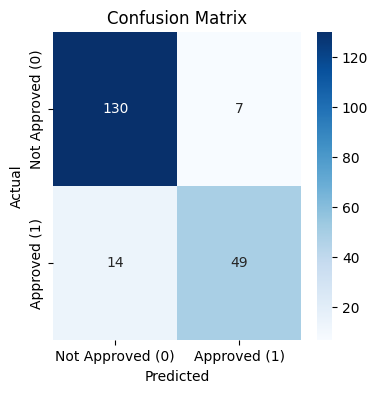

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_predict)

plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Approved (0)", "Approved (1)"],
    yticklabels=["Not Approved (0)", "Approved (1)"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()